In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns

# ML Libraries
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, recall_score, roc_curve, auc, classification_report
from sklearn.preprocessing import label_binarize

# PyTorch Libraries
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [100]:
# 1. Load Dataset
folders = ['F','N','O','S','Z']
labels_map = {f: i for i, f in enumerate(folders)}

X_list = []
y_list = []

dataset_base_path = 'Datasets/Bonn dataset'
for folder in folders:
    folder_path = os.path.join(dataset_base_path, folder)
    
    # Check if folder exists
    if not os.path.exists(folder_path):
        print(f"Warning: Folder {folder_path} does not exist!")
        continue

    for file in sorted(os.listdir(folder_path)):
        if file.endswith(('.txt','.TXT')):
            file_path = os.path.join(folder_path, file)
            try:
                data = np.loadtxt(file_path)
                X_list.append(data)  # shape: (4097,)
                y_list.append(labels_map[folder])
            except Exception as e:
                print(f"Error loading file {file_path}: {e}")

X = np.array(X_list)
y = np.array(y_list)

print(f"Total samples loaded: {len(X)}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Total samples loaded: 500
X shape: (500, 4097)
y shape: (500,)


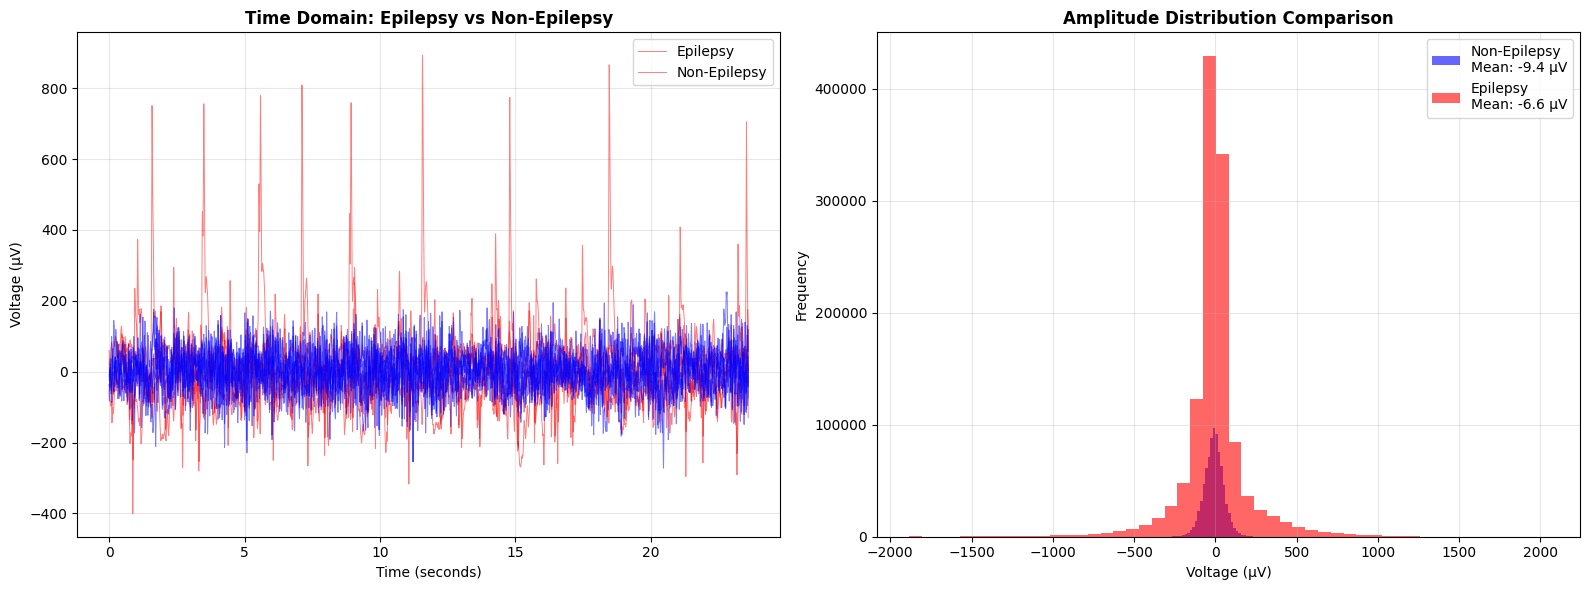


KEY DIFFERENCES BETWEEN EPILEPSY AND NON-EPILEPSY EEG SIGNALS

NON-EPILEPSY (Healthy):
• Regular, rhythmic patterns
• Lower amplitude (typically < 100 μV)
• Dominant alpha waves when eyes closed (8-13 Hz)
• Minimal artifacts and spikes

EPILEPSY PATIENTS:
• Higher amplitude spikes
• Irregular patterns
• Sharp waves and spikes (interictal)
• Rhythmic, high-amplitude discharges (ictal/seizure)
• Increased variability


In [101]:
epilepsy_indices = []
non_epilepsy_indices = []

for i, label in enumerate(y):
    if folders[label] in ['N', 'F', 'S']:  # Epilepsy classes
        epilepsy_indices.append(i)
    else:  # Z or O - Non-epilepsy classes
        non_epilepsy_indices.append(i)

# Simplified version with just the epilepsy vs non-epilepsy comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: Time domain comparison
ax1.set_title('Time Domain: Epilepsy vs Non-Epilepsy', fontsize=12, fontweight='bold')
for idx in epilepsy_indices[:5]:
    signal = X[idx]
    time = np.arange(len(signal)) / 173.61
    ax1.plot(time, signal, 'r-', alpha=0.5, linewidth=0.7)

for idx in non_epilepsy_indices[:5]:
    signal = X[idx]
    time = np.arange(len(signal)) / 173.61
    ax1.plot(time, signal, 'b-', alpha=0.5, linewidth=0.7)

ax1.set_xlabel('Time (seconds)')
ax1.set_ylabel('Voltage (μV)')
ax1.grid(True, alpha=0.3)
ax1.legend(['Epilepsy', 'Non-Epilepsy'])

# Right: Amplitude distribution comparison
ax2.set_title('Amplitude Distribution Comparison', fontsize=12, fontweight='bold')

# Collect all amplitudes
epilepsy_amplitudes = X[epilepsy_indices].flatten()
non_epilepsy_amplitudes = X[non_epilepsy_indices].flatten()

# Plot histograms
ax2.hist(non_epilepsy_amplitudes, bins=50, alpha=0.6, color='blue', 
         label=f'Non-Epilepsy\nMean: {np.mean(non_epilepsy_amplitudes):.1f} μV')
ax2.hist(epilepsy_amplitudes, bins=50, alpha=0.6, color='red',
         label=f'Epilepsy\nMean: {np.mean(epilepsy_amplitudes):.1f} μV')

ax2.set_xlabel('Voltage (μV)')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Key differences summary
print("\n" + "="*60)
print("KEY DIFFERENCES BETWEEN EPILEPSY AND NON-EPILEPSY EEG SIGNALS")
print("="*60)
print("\nNON-EPILEPSY (Healthy):")
print("• Regular, rhythmic patterns")
print("• Lower amplitude (typically < 100 μV)")
print("• Dominant alpha waves when eyes closed (8-13 Hz)")
print("• Minimal artifacts and spikes")

print("\nEPILEPSY PATIENTS:")
print("• Higher amplitude spikes")
print("• Irregular patterns")
print("• Sharp waves and spikes (interictal)")
print("• Rhythmic, high-amplitude discharges (ictal/seizure)")
print("• Increased variability")
print("="*60)

In [102]:
# 2. Feature Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X.reshape(-1, 4097))

X = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-8)
#Reshaping to (N,1,1, 4097)
X = X[:, np.newaxis, np.newaxis, :]

# Prepare K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [103]:
# 3. EEGNet Model

class EEGNet(nn.Module):
    def __init__(self, num_classes=5, chans=1, samples=4097,  # 5 classes, single chan, 4097 time
                 dropout_rate=0.25, kernel_length=64, F1=8, D=2, F2=16):
        super(EEGNet, self).__init__()
        
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, (1, kernel_length), padding=(0, kernel_length//2), bias=False),
            nn.BatchNorm2d(F1),
            nn.Conv2d(F1, F1*D, (chans, 1), groups=F1, bias=False),  # Depthwise (chans=1)
            nn.BatchNorm2d(F1*D),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(dropout_rate)
        )
        
        self.block2 = nn.Sequential(
            nn.Conv2d(F1*D, F1*D, (1, 16), padding=(0, 8), groups=F1*D, bias=False),  # Separable
            nn.Conv2d(F1*D, F2, (1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout(dropout_rate)
        )
        
        # Linear size: After pools (//4 then //8 = //32), so F2 * (samples // 32)
        self.classifier = nn.Linear(F2 * (samples // 32), num_classes)  # ~ F2 * (4097//32) = F2*128

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [104]:
def augment(x):
    # Mild Gaussian noise
    noise = torch.randn_like(x) * 0.02

    # Smaller temporal shift
    shift_amount = torch.randint(-150, 151, (1,)).item()
    shift = torch.roll(x, shifts=shift_amount, dims=-1)
    
    # Gentle amplitude scaling
    scale = 0.9 + torch.rand(1).item() * 0.2 # 0.9–1.1
    
    return scale * x + noise + 0.2 * (shift - x)

In [ ]:
all_true_labels = []
all_pred_labels = []   # argmax predictions
all_pred_probs  = []  # softmax probabilities for ROC

fold_accuracies = []
fold_f1_scores = []
fold_recall_scores = []

patience = 15
epochs_no_improve = 0

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f"\nFold {fold}/5")
    
    X_train_fold = X[train_idx]
    y_train_fold = y[train_idx]
    X_val_fold   = X[val_idx]
    y_val_fold   = y[val_idx]
    
    # To tensors
    train_dataset = TensorDataset(torch.FloatTensor(X_train_fold), torch.LongTensor(y_train_fold))
    val_dataset   = TensorDataset(torch.FloatTensor(X_val_fold),   torch.LongTensor(y_val_fold))
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)  # Smaller batch for small data
    val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False)
    
    model = EEGNet(num_classes=5, chans=1, samples=4097).to(device)  # Adjust num_classes if 4
    optimizer = optim.Adam(model.parameters(), lr=0.0003,weight_decay=1e-4)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=8)
    
    criterion = nn.CrossEntropyLoss()
    
    best_val_f1 = 0.0
    for epoch in range(100):  
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            inputs = augment(inputs) #apply augmentation to everu batch

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        # Validation
        model.eval()
        fold_preds = []
        fold_true  = []
        fold_probs = []   # softmax probabilities for ROC
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                outputs = model(inputs)
                probs = torch.softmax(outputs, dim=1).cpu().numpy()
                _, predicted = torch.max(outputs, 1)
                
                fold_probs.extend(probs)
                fold_preds.extend(predicted.cpu().numpy())
                fold_true.extend(labels.numpy())
        
        acc = accuracy_score(fold_true, fold_preds)
        f1  = f1_score(fold_true, fold_preds, average='macro')
        recall  = recall_score(fold_true, fold_preds, average='macro')
        
        print(f"Epoch {epoch+1} | Loss: {running_loss/len(train_loader):.4f} | Val Acc: {acc:.4f} | Val Recall: {recall: 4f} | Val F1: {f1:.4f}")

        scheduler.step(f1)
        
        if f1 > best_val_f1:
            best_val_f1 = f1
            epochs_no_improve = 0
            best_fold_true = fold_true
            best_fold_preds = fold_preds
            best_fold_probs = fold_probs
        else:
            epochs_no_improve += 1
        
        if epochs_no_improve >= patience:
            print("Early stopping triggered")
            break
    
    # Store for overall metrics
    fold_accuracies.append(acc)
    fold_f1_scores.append(best_val_f1)
    fold_recall_scores.append(recall)
    
    all_true_labels.extend(best_fold_true)
    all_pred_labels.extend(best_fold_preds)
    all_pred_probs.extend(best_fold_probs)


Fold 1/5
Epoch 1 | Loss: 1.6014 | Val Acc: 0.4100 | Val Recall:  0.410000 | Val F1: 0.3853



          FINAL 5-FOLD RESULTS (ALL FOLDS COMBINED)          
Overall Accuracy (500 samples): 0.8160
Mean Fold Accuracy:     0.8160 ± 0.0398
Mean Fold Macro F1:     0.7755 ± 0.0618
Overall Macro Recall:   0.8160
Overall Weighted Recall:0.8160
Overall Macro F1:       0.8121
Overall Weighted F1:    0.8121

Classification Report:
              precision    recall  f1-score   support

           Z       0.84      0.85      0.85       100
           O       0.78      0.92      0.84       100
           N       0.79      0.78      0.78       100
           F       0.98      0.97      0.97       100
           S       0.67      0.56      0.61       100

    accuracy                           0.82       500
   macro avg       0.81      0.82      0.81       500
weighted avg       0.81      0.82      0.81       500



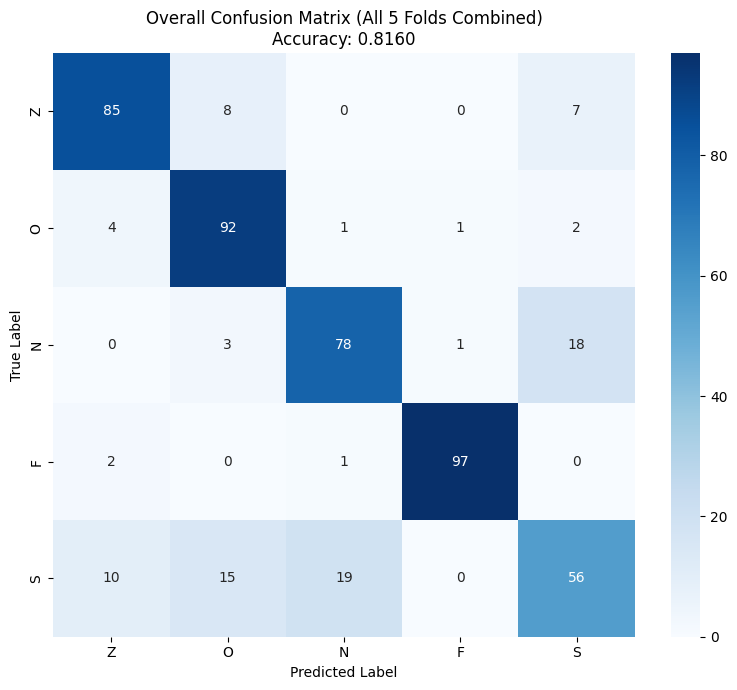

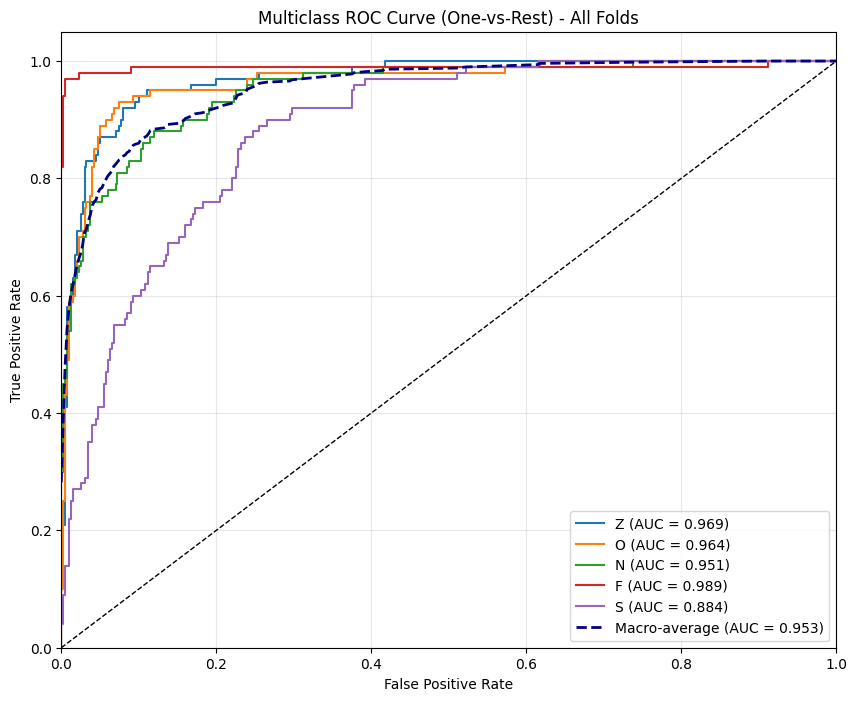

Macro-average ROC AUC: 0.9531


In [ ]:
print("\n" + "="*50)
print("          FINAL 5-FOLD RESULTS (ALL FOLDS COMBINED)          ")
print("="*50)

# Overall Accuracy, F1 and recall
overall_acc = accuracy_score(all_true_labels, all_pred_labels)
overall_f1_macro = f1_score(all_true_labels, all_pred_labels, average='macro')
overall_f1_weighted = f1_score(all_true_labels, all_pred_labels, average='weighted')
overall_recall_macro = recall_score(all_true_labels, all_pred_labels, average='macro')
overall_recall_weighted = recall_score(all_true_labels, all_pred_labels, average='weighted')

print(f"Overall Accuracy (500 samples): {overall_acc:.4f}\n")
print(f"Overall Macro Recall:   {overall_recall_macro:.4f}")
print(f"Overall Weighted Recall:{overall_recall_weighted:.4f}\n")

print(f"Overall Macro F1:       {overall_f1_macro:.4f}")
print(f"Overall Weighted F1:    {overall_f1_weighted:.4f}")

# Detailed per-class report
print("\nClassification Report:")
print(classification_report(all_true_labels, all_pred_labels, target_names=['Z', 'O', 'N', 'F', 'S']))

# ────────────────────────────────────────────────
# Overall Confusion Matrix (one single plot)
# ────────────────────────────────────────────────

cm = confusion_matrix(all_true_labels, all_pred_labels)

plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Z', 'O', 'N', 'F', 'S'],
            yticklabels=['Z', 'O', 'N', 'F', 'S'])
plt.title(f'Overall Confusion Matrix (All 5 Folds Combined)\nAccuracy: {overall_acc:.4f}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# ────────────────────────────────────────────────
# Multiclass ROC Curve (One-vs-Rest)
# ────────────────────────────────────────────────

n_classes = 5
y_true_bin = label_binarize(all_true_labels, classes=range(n_classes))
y_score = np.array(all_pred_probs)

fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'{["Z","O","N","F","S"][i]} (AUC = {roc_auc[i]:.3f})')

# Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
roc_auc_macro = auc(all_fpr, mean_tpr)

plt.plot(all_fpr, mean_tpr, label=f'Macro-average (AUC = {roc_auc_macro:.3f})',
         color='navy', linestyle='--', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve (One-vs-Rest) - All Folds')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Macro-average ROC AUC: {roc_auc_macro:.4f}")